# 9. Plotting with Python (matplotlib) — homework 

### Exercise 9.1

Plot functions sin(x), cos(x), and exp(-x) in a range `[0,10]` in the same figure. Colors are red, green, and blue, respectively. Lines are solid, dashed, and dotted, respectively. Add a legend. 

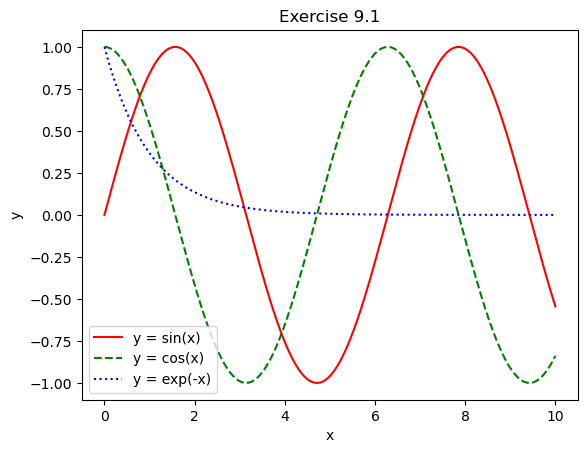

In [1]:
from matplotlib import pyplot as plt
import numpy as np

x = np.linspace(0,10,1000)

sin = np.sin(x)
cos = np.cos(x)
exp = np.exp(x*-1)

plt.plot(x, sin, 'r-', label='y = sin(x)')
plt.plot(x, cos, 'g--', label='y = cos(x)')
plt.plot(x, exp, 'b:', label='y = exp(-x)')

plt.legend()
plt.title("Exercise 9.1")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

### Exercise 9.2

Generate n=100 random points in a unit square [0,1]x[0,1]. Points are green if the distance from (0,0) is less then 1; they are red otherwise. The marker area of a point (x,y) should be proportional to |x|+|y|. 

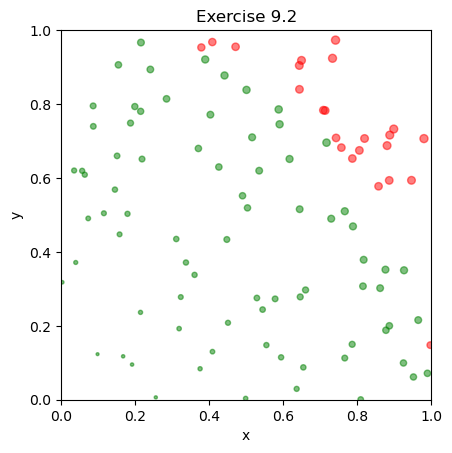

In [2]:
from matplotlib import pyplot as plt
import numpy as np

n = 100
x = np.random.rand(n)
y = np.random.rand(n)

colors = np.where((x**2 + y**2 > 1) ,'r', 'g')
area = 20*(x + y)   #no need for || as both values are non-negative

plt.scatter(x, y, s=area, c=colors, alpha=0.5)
plt.axis('scaled')  #a square grid
plt.axis([0, 1, 0, 1])
plt.title("Exercise 9.2")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

### Exercise 9.3

Create a function that calculates, for the point (x,y), the sum of distances from two points in the plane: (-1,0) and (1,0). Show the function values using `imshow()`. 

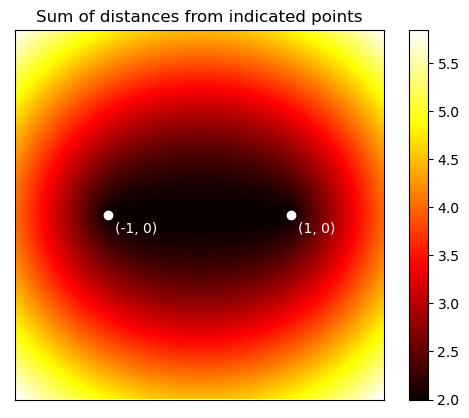

In [3]:
from matplotlib import pyplot as plt
import numpy as np

#preaparing mesh
x = np.linspace(-2,2,101)
y = np.linspace(-2,2,101)
xx, yy = np.meshgrid(x, y)

#focal points
ps = [(-1,0), (1,0)]

#data
data = sum([np.sqrt((xx-p[0])**2 + (yy-p[1])**2) for p in ps])

#plotting the data
plt.imshow(data, cmap='hot', interpolation='bilinear')
plt.colorbar()
plt.title('Sum of distances from indicated points')

#hiding ticks (they do not represent actual coordinates)
plt.xticks([])
plt.yticks([])

#finding the posion of focal points by pixel count of imshow()
ps_indexs = [(np.searchsorted(x, p[0]), np.searchsorted(y, p[1])) for p in ps]

#finding the posion for text labels
text_offset = (0.05, 0.2)
ps_texts = [(np.searchsorted(x, p[0]+text_offset[0]), np.searchsorted(y, p[1]+text_offset[1])) for p in ps]

#adding the folcal points of the image
ax = plt.gca()
for i, psi in enumerate(ps_indexs):
    ax.plot(psi[0], psi[1], 'wo')
    ax.annotate(f'({ps[i][0]}, {ps[i][1]})', ps_texts[i], color='w')
